This exercise is part of the [ECLR](https://datasquad.github.io/ECLR/) page.

## Introduction

In this section, you will learn how to handle time-series data using Python. We'll explore various techniques for identifying key characteristics of time-series data, such as trends, seasonality, and autocorrelation. Additionally, you will learn how to implement basic time-series modeling approaches to make forecasts.

# Packages and codes used

In this Python workthrough, we will use and import the following libraries. If you get an error message like `No module named 'statsmodels'` Python is telling you that this package is not yet installed. Install the package by going to your Terminal and using the following command (if it is the `statsmodels` package that is not yet installed): `pip install statsmodels`. Check out this [walkthrough](https://datasquad.github.io/ECLR/Py_coding/Py_Libraries.html).

In [ ]:
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations
from lets_plot import *  # For advanced and interactive plots
from statsmodels.api import OLS, add_constant  # For regression modeling
from statsmodels.stats.sandwich_covariance import cov_hac, cov_white_simple  # For robust standard errors
from statsmodels.tsa.stattools import adfuller  # For Augmented Dickey-Fuller tests
import requests  # For making HTTP requests to web servers for data retrieval
from io import StringIO  # For creating in-memory text streams which behave like files

# Lets_plot requires a setup
LetsPlot.setup_html()


| Library/Function                                | Description |
|-------------------------------------------------|-------------|
| `pandas`                                        | Used for handling and manipulating datasets in tabular format. |
| `numpy`                                         | Provides efficient numerical operations, including array manipulations and mathematical functions. |
| `lets_plot`                                     | Inspired by R's ggplot2, it allows creating advanced and interactive plots directly within Python. |
| `statsmodels.api`                               | Provides a framework for statistical modeling, including Ordinary Least Squares (OLS) regression. |
| `statsmodels.stats.sandwich_covariance`         | Contains methods for computing robust standard errors. |
| - `cov_hac`                                     | Computes Newey-West standard errors for heteroskedasticity and autocorrelation corrections. |
| - `cov_white_simple`                            | Computes White’s robust standard errors for heteroskedasticity correction. |
| `statsmodels.tsa.stattools`                     | Contains functions for time series analysis. |
| `requests`                                      | Used to make HTTP requests to download data from the web. |
| `from io import StringIO`                       | Used for handling text I/O operations, enabling the manipulation of string data as if it were a file. |


# A single time series
## Import data

We shall use some data from the Office for National Statistics (ONS) in the UK. Let's say we wish to look at GDP data from the UK. There are a lot of different ways to measure GDP. Here we are using a particular series, the [ `AMBI` series in the `UKEA` database](https://www.ons.gov.uk/economy/grossdomesticproductgdp/timeseries/abmi/ukea).

- **Obtain the Data Manually or via an API**: Use the [ONS Time Series Tool](https://www.ons.gov.uk/timeseriestool) to locate and download the data. For example, search for the `AMBI` series in the `UKEA` databank. Display the data as a table and chose the required frequency (say annual data).
- **Process the Data in Python**: After downloading the dataset as a CSV file, you can use `pandas` to load and analyze the data.

When you get data from the ONS, you need to know the series ID and which ONS dataset you can find. To find that info, go to the [ONS time series tool](https://www.ons.gov.uk/timeseriestool). 

Go to the [`AMBI` series in the `UKEA` database](https://www.ons.gov.uk/economy/grossdomesticproductgdp/timeseries/abmi/ukea) and download the annual data as a csv file. Save that file with the name `ONS_AMBI.csv` in your working directory. 

In [73]:
# Load the CSV file into a DataFrame
gdp_annual = pd.read_csv('../data/ONS_AMBI.csv')
gdp_annual.head(10)

,Title,Gross Domestic Product: chained volume measures: Seasonally adjusted £m
0,CDID,ABMI
1,Source dataset ID,UKEA
2,PreUnit,£
3,Unit,m
4,Release date,23-12-2024
5,Next release,28 March 2025
6,Important notes,NaN
7,1948,422621
8,1949,436620
9,1950,451212


As you can see from looking at the first 10 rows, the data only start in row 7 (or the 8th row). This is very typical for ONS datasets as they put identifying information in the first few rows. However, for the analysis we do not need these data. You can instruct `pd.read_csv` to ignore some initial rows. By ignoring initial rows we do loose any information that could be used to name the columns and therefore we will also name the columns as we load the data.

In [74]:
gdp_annual = pd.read_csv('../data/ONS_AMBI.csv', skiprows=8, names=['Date', 'GDP'])
gdp_annual.head()

,Date,GDP
0,1948,422621
1,1949,436620
2,1950,451212
3,1951,467977
4,1952,474994


You can see that the structure of `gdp_annual` now seems to be ok. Let's check the `.info()` method to see what formats the variables have.

In [75]:
gdp_annual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    355 non-null    object
 1   GDP     355 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 5.7+ KB


You can see that the `Year` variable is an object variable (Python's way of saying "I cannot identify the data type.") and the `GDP` has been recognised as a number. Above we could see that the first observation is from 1948. From the `.info()` output we can note that there are 355 rows with data. Clearly this does not make sense. Let's investigate what is going on.

In [76]:
gdp_annual.iloc[70:80]

,Date,GDP
70,2018,2434694
71,2019,2474245
72,2020,2219474
73,2021,2409815
74,2022,2526428
75,2023,2536090
76,1955 Q1,134886
77,1955 Q2,134924
78,1955 Q3,137592
79,1955 Q4,136813


Here you can see that the annual data reach in to row 75, after that we get quarterly GDP data (from 1955 Q1 onwards). This is a feature (or rather quirk) af the date when they are downloaded from the ONS webpage. Different frequencies are saved in the same file. 

Let is therefore divide the datafile into one with quarterly and one with annual observations. (Note, when this file was downloaded the last annual observation was from 2023 and the last quarterly observation was from 2024 Q3. If you load this file such that more data are available you may have to adjust the split below accordingly.)

In [77]:
gdp_quarterly = gdp_annual.iloc[76:]
gdp_annual = gdp_annual.iloc[:76]

At this stage Python does not know that the data we are dealing with are time-series data. We do that by formatting the Date variable as date format. To do so we use the `pd.to_datetime()` function. We feed in the year but attach `-12-31` to the year. This is as this dateformat requires a particular day. So we associate the annual GDP with the last day of the year. You could have also chose to associate it to the middle of the year, say `-06-30`. 

In [78]:
gdp_annual['Year'] = gdp_annual['Date'] # to keep the Year only as a variable
gdp_annual['Date'] = pd.to_datetime(gdp_annual['Date'].astype(str) + '-12-31')
gdp_annual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    76 non-null     datetime64[ns]
 1   GDP     76 non-null     int64         
 2   Year    76 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.9+ KB


We do the same for the quarterly data. Here, however, we will first have to replace the `Q1` to `Q4` labels with the respective end of quarter days. This is done using the `.str.replace()` function.

In [79]:
    # Replace 'Q1', 'Q2', etc., with corresponding end-of-quarter dates
    gdp_quarterly['Date'] = gdp_quarterly['Date'].str.replace(
        r' Q1', '-03-31').str.replace(
        r' Q2', '-06-30').str.replace(
        r' Q3', '-09-30').str.replace(
        r' Q4', '-12-31')

Now we can again apply the `pd.to_datetime()` function.

In [80]:
gdp_quarterly['Date'] = pd.to_datetime(gdp_quarterly['Date'])

---
### Can I access data directly from the ONS
[//]: # (-.- .tabset)

#### The task

The process described above of finding data on some organisation's website (like the ONS), downloading them as a csv file and then loading them into Python appears a little pedestrian. Can I access the data directly from the ONS without first downloading a csv file?

#### The general answer

Yes, this is possible. The ONS allows you to access the data directly through what is called an Application Programme Interface (API). If you know the datastructure, the series identifier and how the ONS wnats you to communicate with its database this can be done.

#### An example

In this example we show how you can access the annual data from the ONS directly. If you do this often you will quickly get familiar with the required syntax. However, we believe that for the occasional user it is easier to download the data via a csv file. You can find more guidance from the [ONS](https://digitalblog.ons.gov.uk/2021/02/15/how-to-access-data-from-the-ons-beta-api/).

In [81]:
# URL of the dataset
url = "https://www.ons.gov.uk/generator?format=csv&uri=/economy/grossdomesticproductgdp/timeseries/abmi/ukea"

# Fetch the dataset using requests
response = requests.get(url)

if response.status_code == 200:
    print("Dataset fetched successfully for Yearly data.")
    
    # Load yearly data while skipping metadata rows
    csv_data_yearly = StringIO(response.text)
    yearly_data_api = pd.read_csv(csv_data_yearly, skiprows=8, nrows=76, names=['Year', 'Real GDP'])

    # Convert 'Year' to datetime, setting year-end as date
    yearly_data_api['Year'] = pd.to_datetime(yearly_data_api['Year'].astype(str) + '-12-31')

    # Set 'Year' as the index
    yearly_data_api.set_index('Year', inplace=True)

    # For display purposes: Show only the year part of the index
    display_data_api = yearly_data_api.copy()
    display_data_api.index = display_data_api.index.year

    print("\nYearly Dataset:")
    print(display_data_api.head())
else:
    print(f"Failed to fetch dataset for Yearly data. HTTP Status Code: {response.status_code}")


Dataset fetched successfully for Yearly data.

Yearly Dataset:
      Real GDP
Year          
1948    422621
1949    436620
1950    451212
1951    467977
1952    474994


#### 
[//]: # (-.- .unlisted .unnumbered)

---

## Time Series Plots

With `lets-plot` in Python, you can easily visualize data series with a syntax that is intuitive and flexible. This library provides a clear, concise way to describe the visual representation of data, focusing on the aesthetics and relationships you want to highlight. It is based on the syntax used for the `ggplot` library in R. Whether you're plotting simple line graphs or complex multi-layered visualizations, `lets-plot` enables a straightforward approach to plotting by allowing you to layer components with simple commands. This method is particularly useful for exploratory data analysis where visual consistency and readability are key.

There are other powerful plotting tools available in Python. In particular `matplitlib` is popular.

Let's plot the **quarterly** data

In [82]:
# Try plotting with simplified data and no custom axis formatting
plot_a = ggplot(gdp_annual, aes(x='Year', y='GDP')) + \
    geom_line(color='black', size=1) + \
    ggtitle('Real GDP Over Time') + \
    xlab('Year') + \
    ylab('Real GDP')

# Display the plot
plot_a.show()

And now we do the same with the quarterly data.

In [83]:
# Try plotting with simplified data and no custom axis formatting
plot_q = ggplot(gdp_quarterly, aes(x='Date', y='GDP')) + \
    geom_line(color='black', size=1) + \
    ggtitle('Real GDP Over Time') + \
    xlab('Date') + \
    ylab('Real GDP')

# Display the plot
plot_q.show()

You can see that the labelling on the x-axis has not placed the correct labelling on the x-axis. One way to deal with this is to extract the date as text and use that for the axis labelling.

In [84]:
gdp_quarterly['Quarter'] = gdp_quarterly['Date'].dt.strftime('%y-%m')  # Ensure plain string format

you can refer to [this page](https://www.w3schools.com/python/python_datetime.asp) to understand how the `dt.strftime()` function was applied to extract a printable version of the date.

In [85]:
plot_q = ggplot(gdp_quarterly, aes(x='Quarter', y='GDP')) + \
    geom_line(color='black', size=1) + \
    ggtitle('Real GDP Over Time') + \
    xlab('Quarter') + \
    ylab('Real GDP')

# Display the plot
plot_q.show()

---
### Practice your skill
[//]: # (-.- .tabset)

#### The task

You want to have a closer lok at the GDP development since 2000 to see what happened to GDP during the financial crisis and the Covid period. In the above plots this is difficult to see as this period only makes for a small fraction of the plot. Create a plot of quarterly GDP only using data from 2000 Q1 onwards.

#### Step 1: Prepare the data

We already have all the data we need in `gdp_quarterly`. We merely need to restrict the data to those after 1999-12-31. Let's create a temporary dataset `temp` which only has the data we wish to display.


In [86]:
# let's define a temporary dataset
temp = gdp_quarterly.loc[gdp_quarterly['Date'] >= '2000-01-01']

#### Step 2: Plot the data

Now we apply the same plotting routine as above.

In [87]:
plot_q2 = ggplot(temp, aes(x='Quarter', y='GDP')) + \
    geom_line(color='black', size=1) + \
    ggtitle('Real GDP Over Time') + \
    xlab('Quarter') + \
    ylab('Real GDP')

# Display the plot
plot_q2.show()

#### 
[//]: # (-.- .unlisted .unnumbered)

---


[//]: # (-.- .unlisted .unnumbered)

## Autocorrelation Function (ACF)

Let's compute the autocorrelation function (ACF). The ACF describes the relationship between a time series $y_t$ and its own past values lagged by $k$ periods, expressed as $\text{corr}(y_t, y_{t-k})$, for various values of $k$. To calculate and plot the Autocorrelation Function (ACF) in Python, we typically use the statsmodels library, which provides comprehensive statistical functions, including autocorrelation and partial autocorrelation functions. Specifically, you can use the `acf` function from the `statsmodels.tsa.stattools` module to compute the autocorrelation function for a given time series. This function quantifies how much a series is influenced by its previous values, providing insights into the temporal dependencies within the data.


In [88]:
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
# Calculate the autocorrelation function up to 20 lags
acf_values = acf(gdp_annual['GDP'], nlags=20, fft=True)

The object `acf_values` contains the autocorrelations up to lak $k=20$. You can easily visualise these using the `plot_acf` function (imported from `statsmodels.graphics.tsaplots`).

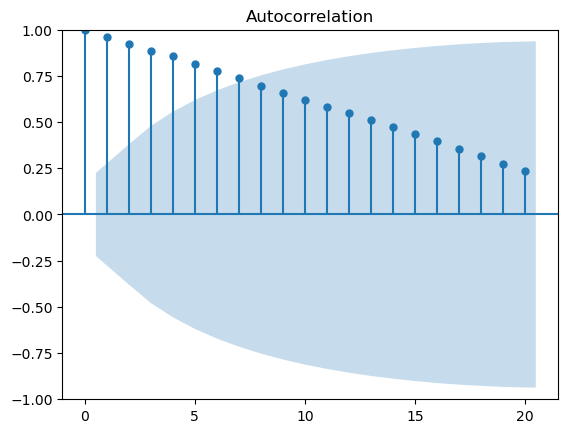

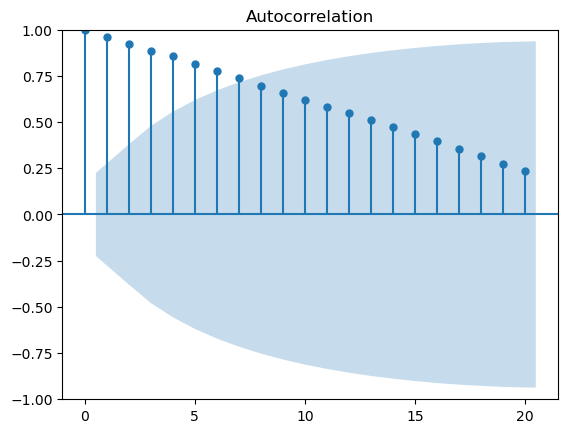

In [89]:
plot_acf(gdp_annual['GDP'], lags=20)

From the autocorrelation plot we can observe the following:

1. **First Value at Lag 0**:
The autocorrelation function always begins with a value of 1 at lag 0, indicating that any time series is perfectly correlated with itself without any delay. Mathematically, this is expressed as $ \text{corr}(y_t, y_t) = 1 $.

2.  **Representation in the Plot** :
The plot, as described, starts with the autocorrelation coefficient at lag 0 set to 1 and continues to higher lags. It depicts a decreasing trend in the autocorrelation of Yearly GDP data as the lags increase, a common phenomenon observed in economic time series analyses.

3. **Interpretation of Higher Lags**:
With increasing lags, the autocorrelation coefficients generally diminish, suggesting that the influence of past values on current observations decreases as the time gap between them widens. The described plot appears to capture this gradual decay in autocorrelation, which may stabilize or turn negative, reflecting varied patterns of temporal relationships within the data.

4. **Confidence intervals**:
The shaded areas give you a confidence intervall. Values outside the confidence intervall are values we judge to be statistically significant, i.e. different from 0.



[//]: # (-.- .unlisted .unnumbered)

# Multiple time series

Often we will deal with multiple time-series. Now you will learn how to deal with multiple series, store the data, plot them and calculate ACFs. When dealing with multiple time series in Python, you'll often need to download, manipulate, and analyze data from different sources. Let's go through the process using Python tools:

1. **Downloading Data**: We can retrieve data such as female unemployment rates and monthly inflation rates from online sources, like the [ONS database](https://www.ons.gov.uk/timeseriestool). This can be done using libraries like `requests` for web scraping or APIs, or `pandas_datareader` if the data source is supported. Here, however we use the pedestrian method, meaning we download a datafile from a data providers website (here the UK's Office for national Statistics, ONS) and then we upload the data into Python.

2. **Data Preparation**: Once downloaded, the data typically needs to be formatted into a structure conducive to analysis. In Python, this often means transforming the data into a long format using `pandas`, which makes it easier to handle multiple time series in a unified way.

We download female unemployment (`series ID:YCPL` and `ONS dataset: LMS`)  and monthly inflation rates (`series ID: D7OE` and `ONS dataset:MM23`) from the [ONS database](https://www.ons.gov.uk/timeseriestool). On both occasions, we put the data in a long format.

[//]: # (-.- .tabset)

## Import Female unemployment rate and inflation rate

### Step 1: Identify the data series

The first step is always to identify the particular series you wish to work with. You may have found the series identifier in a paper you read or you looked on the ONS website for different unemployment and inflation rates and identified the series you want to work with. Let's assume that through your research you have identified the following two series you wish to work with:

* [Female unemployment rate (series identifier: YCPL)](https://www.ons.gov.uk/employmentandlabourmarket/peoplenotinwork/unemployment/timeseries/ycpl/lms)
* [Monthly PI inflation rate (series identifier: D7OE)](https://www.ons.gov.uk/economy/inflationandpriceindices/timeseries/d7oe/mm23)

For each of these series you can download the data in scv format. Let's save these in the following files `ONS_YCPL_monthly.csv` and `ONS_D7OE_monthly.csv` and save these in your working directory. The data we are working with here go up to Dec 2024 for TCPL and January 2025 for D7OE.

### Step 2: Load data into Python

This is a simple upload using the `pd.read_csv()` function. As these are typical ONS files we need to skip the first 8 roes again.

In [90]:
fur_monthly = pd.read_csv('../data/ONS_YCPL_monthly.csv', skiprows=8, names=['Date', 'Female_UR'])
fur_monthly.head()

,Date,Female_UR
0,1992,7.6
1,1993,7.9
2,1994,7.3
3,1995,6.8
4,1996,6.4


In [91]:
inf_monthly = pd.read_csv('../data/ONS_D7OE_monthly.csv', skiprows=8, names=['Date', 'Inf'])
inf_monthly.head()

,Date,Inf
0,1988 FEB,0.3
1,1988 MAR,0.3
2,1988 APR,1.2
3,1988 MAY,0.5
4,1988 JUN,0.4


The inflation rate data begin with monthly data, whereas the unemployment rate data have initially annual data (foollowed by quarterly data). We therefore have to extract the monthly data. In the version of the datafile used here they begin from row 172 onwards, the first monthly observation being for April 1992.

In [92]:
fur_monthly = fur_monthly.iloc[164:]

We will want to convert the information in the `Date` column into date variables again.

In [93]:
fur_monthly['Date'] = pd.to_datetime(fur_monthly['Date'], format='%Y %b', errors='coerce')
inf_monthly['Date'] = pd.to_datetime(inf_monthly['Date'], format='%Y %b', errors='coerce')

The `%Y %b` format string specifies that the date is in the format `Year Month`. The `errors` parameter is set to `coerce` to handle any errors that may arise during the conversion process.

### Step 3: Merge Data

Both files have the same structure, a `Date` variable and then a variable with the respective data. This should make merging the data straightforward.

In [94]:
month_data = fur_monthly.merge(inf_monthly, on='Date', how='inner')

in order to understand what the option `how  = inner` achieves it is best to experiment with other options. Check out the [help page for this function](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html) to see what other options are available. 

let us also ensure that for the remaining work we restrict ourselves to data up to and including December 2024.

In [95]:
month_data = month_data[month_data['Date'] <= '2024-12-31']
month_data.head()

,Date,Female_UR,Inf
0,1992-04-01,7.6,1.1
1,1992-05-01,7.6,0.3
2,1992-06-01,7.7,0.0
3,1992-07-01,7.6,-0.5
4,1992-08-01,7.5,0.1


### Step 4: Create a long dataformat

The data above are in what is often called a wide data format. Different variables (for the same time) show in different columns. It is often useful (especially for graphing) to have the data also in a long format. In the long format we do have a row for each time-variable combination. For instance for April 1992 (the first observation) we would have two rows, one for the female unemployment rate and another for the inflation rate.

In [96]:
# Convert month_data to long format
month_data_long = pd.melt(month_data, id_vars=['Date'], value_vars=['Female_UR', 'Inf'], 
                          var_name='Variable', value_name='Value')

# Display the transformed dataset, all rows for April 1992
month_data_long[month_data_long['Date'] == '1992-04-01']

,Date,Variable,Value
0,1992-04-01,Female_UR,7.6
393,1992-04-01,Inf,1.1


Compare the structures of `month_data` and `month_data_long` to understand the difference and how the `pd.melt` function allowed us to move from the former o the latter.

### 
[//]: # (-.- .unlisted .unnumbered)

---

[//]: # (-.- .unlisted .unnumbered)

## Plotting multiple time series

Let's plot multiple time series.

In [97]:
temp_ur = month_data_long.loc[month_data_long['Variable'] == 'Female_UR']
temp_inf = month_data_long.loc[month_data_long['Variable'] == 'Inf']

# Create plot for Female Unemployment Rate
plot_unemp = ggplot(temp_ur, aes(x='Date', y='Value')) + \
    geom_line(color='blue', size=1.0) + \
    ggtitle("Female Unemployment Rate") + \
    xlab("Date") + \
    ylab("Rate (%)") + \
    theme_minimal()

# Create plot for Inflation Rate
plot_inflation = ggplot(temp_inf, aes(x='Date', y='Value')) + \
    geom_line(color='blue', size=1.0) + \
    ggtitle("Inflation Rate") + \
    xlab("Date") + \
    ylab("Rate (%)") + \
    theme_minimal()

# Combine the two plots side-by-side
combined_plots = gggrid([plot_unemp, plot_inflation], ncol=2)

# Show the combined plot
combined_plots.show()


In Python, we utilized the `Lets-Plot` library and its `gggrid` function to create a layout similar to `grid.arrange(p1, p2, nrow=1, ncol=2)` in R. This method allowed us to arrange two plots side by side in a single row, making it visually effective for comparing related datasets, such as the female unemployment rate and the inflation rate.

The `gggrid` function simplifies combining multiple plots by specifying the number of columns (`ncol=2`) to arrange the plots horizontally. Each subplot is separately created using `ggplot` and populated with aesthetics, titles, and labels that suit its respective dataset. For instance:

The first plot visualizes the female unemployment rate with clear axes, a blue line, and a descriptive title.
The second plot displays the inflation rate with similar styling for consistency.

What if we want to combine the two time-series into one graph (this makes sense if they exist on a similar scale)? In this case, we can use the `Lets-Plot `library. The code filters the combined dataset to include only the selected series and uses `ggplot` to plot them with different colours based on the `id` variable:

In [98]:

# Create the plot
plot_combined = ggplot(month_data_long, aes(x='Date', y='Value', color='Variable')) + \
    geom_line(size=1.0) + \
    ggtitle("Various Time-Series") + \
    xlab("Date") + \
    ylab("Value") + \
    theme_minimal() + \
    scale_color_manual(values=['red', 'cyan'])  # Custom colors for the two series

# Display the plot
plot_combined.show()


This is fairly straightforward. The `color='Variable` option in the initial setup told Python to create different lines for the different `variables` values. as we only have two different series in `month_data_long` this created two lines. If we had more different series, more lines would have been plotted.

let us now also add autocorrelation function plots to the picture. First we need t create these plots.

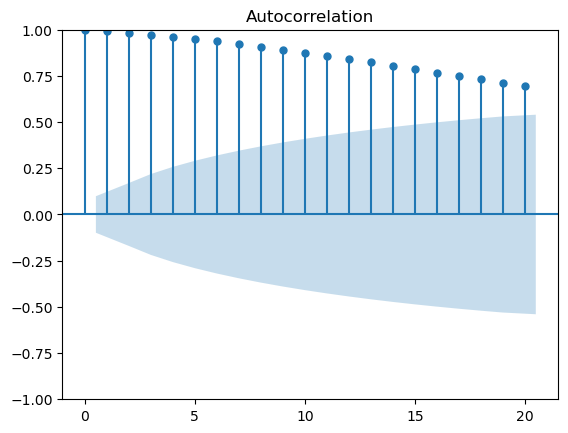

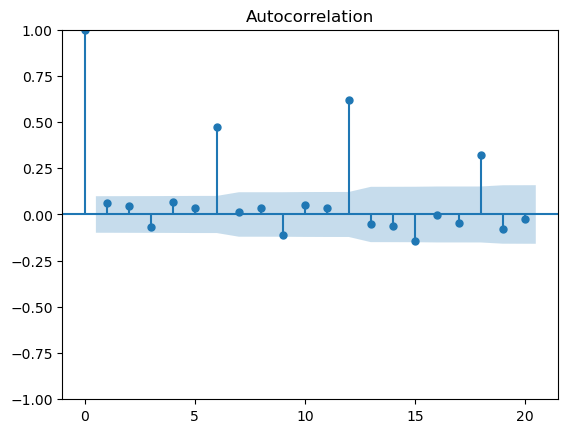

In [99]:
plot_ur_acf = plot_acf(temp_ur['Value'], lags=20)
plot_inf_acf = plot_acf(temp_inf['Value'], lags=20)

Let's see whether we can combine these plots (two line plots and two ACF plots) into one figure. You can try the code below.

In [100]:
# Combine plots in a 2x2 grid
# gggrid([plot_inflation, plot_unemp, plot_inf_acf, plot_ur_acf],ncol=2).show()

You are likely to get an error message like this: "AttributeError: 'Figure' object has no attribute 'as_dict". The reason is that `ggplot` and `acf_plot` produce different types of plots. `gggrid` only works with plots which are created by `ggplot`. One could of course create a new dataframes with the autocorrelations you get from applying the `acf` function (see above) and then use these to create an acf plots with `ggplot` which could then be combined with the line plots. But on this occasion this may not be worth the effort.


As you can see, the female unemployment series shows a slowly decaying autocorrelation function (ACF), a hallmark of non-stationary data. Dealing with nonstationary data can be tricky and may lead to spurious results. One strategy often applied is to difference a series, or calculate a growth rate.

Let's do that for the unemployment series, the inflation series already looks stationary.


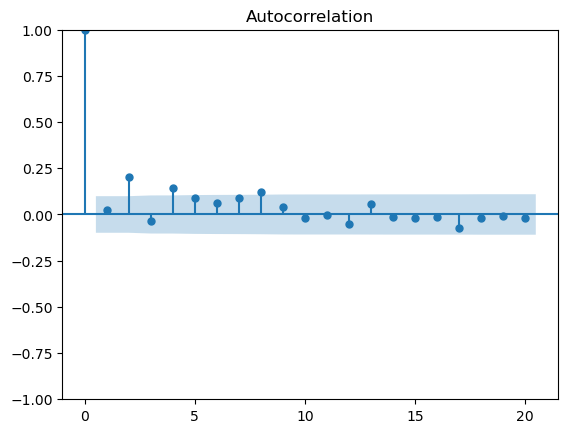

In [101]:
# Create log-differenced series (growth rates)
month_data['l_F_UR'] = np.log(month_data['Female_UR'])
month_data['l_F_UR'] = month_data['l_F_UR'].diff() # the log difference approximates the growth rate

# now plot acf for the log-differenced series, need to drop missing values!
plot_gfur_acf = plot_acf(month_data['l_F_UR'].dropna(), lags=20)

From here you can see that by (log)differencing the data, the ACF has basically collapsed to 0 and we are now looking at a stationary series.

While formal tests like the Augmented Dickey-Fuller (ADF) test provide a rigorous way to assess stationarity, visually analyzing ACF plots offers a straightforward and insightful method to identify non-stationarity and evaluate the impact of such transformations.

# Simple Time Series Regression Analysis

Using time series regression, let's run a simple regression model to explore the relationship between economic growth and unemployment. The objective is to understand how changes in Real GDP influence the unemployment rate over time. 

### The Regression Model

We use a simple linear regression model where the dependent variable is the unemployment rate transformed from monthly to quarterly frequency, and the independent variable is the quarterly Real GDP data. 

The regression equation is mathematically represented as follows:

$$ U_t = \beta_0 + \beta_1 \cdot GDP_t + \epsilon_t $$

**Where:**

- $U_t$: Unemployment rate at time $t$
- $GDP_t$: Real Gross Domestic Product at time $t$
- $\beta_0$: Intercept of the regression line
- $\beta_1$: Slope of the regression line, indicating the change in unemployment rate for a one unit change in Real GDP
- $\epsilon_t$: Error term at time $t$, representing the discrepancy between observed values and those predicted by the model

### Objective

The analysis will provide insights into how economic growth, as indicated by changes in Real GDP, affects labour market conditions, precisely the unemployment rate. This could be important for policymakers and economic analysts focusing on employment strategies and economic planning.

GDP data are only observed once every quarter. Currently the unemployment data are monthly data and therefore, before we can merge GDP and unemployment data into a quarterly dataset we need to transform the unemployment data to a quarterly frequency. Let's first create a new dataset from which we convert

In [102]:
mtq_data = month_data[['Date','Female_UR','Inf']]   # only the data needed to convert to quarterly

Now we can use the `resample` method to convert this to quarterly data. For this to work we need the `Date` variable, which contains the date information in the `datetime` format as the index of `mtq_data`. Then we can apply the resample method, asking Python to take the mean value of all months in a quarter.

In [103]:
# Ensure the 'Date' column is set as the index
mtq_data.set_index('Date', inplace=True)

# Resample to quarterly frequency and aggregate using the mean
quarterly_data = mtq_data.resample('Q').mean()

# Reset the index to make 'Date' a column again
quarterly_data.reset_index(inplace=True)

# Display the first few rows of the aggregated quarterly data
print(quarterly_data.head())

        Date  Female_UR       Inf
0 1992-06-30   7.633333  0.466667
1 1992-09-30   7.566667 -0.033333
2 1992-12-31   7.866667  0.166667
3 1993-03-31   8.066667  0.200000
4 1993-06-30   7.966667  0.466667


Compare the data in `quarterly_data` to those in `month_data` to confirm that indeed you find the quarterly averages. 

In [104]:
print(month_data.head(6))

        Date  Female_UR  Inf    l_F_UR
0 1992-04-01        7.6  1.1       NaN
1 1992-05-01        7.6  0.3  0.000000
2 1992-06-01        7.7  0.0  0.013072
3 1992-07-01        7.6 -0.5 -0.013072
4 1992-08-01        7.5  0.1 -0.013245
5 1992-09-01        7.6  0.3  0.013245


You may remember that there were also quarterly data in the original datafile we downloaded from the ONS. That would be an alternative way to get quarterly data. They will not be exactly the same as the data we created here, but very similar.

Now we want to merge the quarterly GDP data into the `quarterly_data`. 

In [105]:
print(gdp_quarterly.head())

         Date     GDP Quarter
76 1955-03-31  134886   55-03
77 1955-06-30  134924   55-06
78 1955-09-30  137592   55-09
79 1955-12-31  136813   55-12
80 1956-03-31  138343   56-03


This looks as if we should be able to merge this straight into `quarterly_data`.

In [106]:
quarterly_data = quarterly_data.merge(gdp_quarterly, on='Date', how='inner')

The data is in a wide format, which is ideal for regression analysis, where each variable (CPI Inflation and Unemployment Rate) occupies its own column. 

We can now feed the data into the `smf` from `statsmodelsformula.api` function for fitting the ordinary least squares regression, and then display the results using  the [stargazer_HAC.py](https://github.com/SimoKF/Drafting-Python-resources-for-ECLR/blob/main/stargazer_hac.ipynb) package. Before actually running the model, it is important to ensure that the "Quarter" column exists in both datasets. We can do this by running the following code:

In [107]:
import statsmodels.formula.api as smf
mod1 = smf.ols(formula="Female_UR ~ GDP", data = quarterly_data)
mod1_res = mod1.fit()
print(mod1_res.summary())

                            OLS Regression Results                            
Dep. Variable:              Female_UR   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     59.67
Date:                Tue, 25 Mar 2025   Prob (F-statistic):           2.85e-12
Time:                        16:29:58   Log-Likelihood:                -193.76
No. Observations:                 130   AIC:                             391.5
Df Residuals:                     128   BIC:                             397.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.8263      0.576     17.054      0.0

When we estimate time-series regression models we often work with the assumption that the error terms could be autocorrelated. If that is the case the standard errors for the regresison coefficients ought to be calculated in way that makes them robust to this pattern. The standard errrs of choice are Heteroskedasticity and Autocorrelation Consistent (HAC) standard errors, sometimes called Newey-West standdard errors. Calculating thise is quite straightforward.

In [110]:
mod1_HAC = mod1_res.get_robustcov_results(cov_type='HAC', maxlags=1)
print(mod1_HAC.summary())

                            OLS Regression Results                            
Dep. Variable:              Female_UR   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     67.02
Date:                Tue, 25 Mar 2025   Prob (F-statistic):           2.34e-13
Time:                        17:23:26   Log-Likelihood:                -193.76
No. Observations:                 130   AIC:                             391.5
Df Residuals:                     128   BIC:                             397.3
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.8263      0.566     17.347      0.0

The coefficients remain unchanged but the standard errors change.

The coefficient for GDP is negative and small (-8.629e-06) with a very small p-value, indicating statistical significance at a p-value less than 0.01. This seems to suggest that higher GDP significantly reduces the unemployment rate.

Let’s have a look at the residuals.

In [112]:
# Assuming 'model' is your fitted regression model from statsmodels
residuals = mod1_res.resid

# Create a DataFrame for plotting
data = pd.DataFrame({
    'Residuals': residuals,
    'Index': np.arange(len(residuals))
})

# Plot residuals
p1 = ggplot(data, aes('Index', 'Residuals')) + \
    geom_line() + \
    ggtitle('Model 1 - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Calculate ACF for residuals
acf_res = acf(residuals, nlags=20, fft=False)

# Create a DataFrame for the ACF
acf_data = pd.DataFrame({
    'ACF': acf_res,
    'Lag': range(len(acf_res))
})

# Plot ACF
p2 = ggplot(acf_data, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color="red", linetype="dashed", size=0.5) + \
    ggtitle('Series model1 Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Combine the two plots side-by-side
combined_plots = gggrid([p1, p2], ncol=2)

# Show the combined plot
combined_plots.show()


Important observations:

1. **Residuals Plot**: The line graph showing the residuals are very persistent. 
2. **ACF Plot**: The bar chart showing the ACF of the residuals provides direct evidence regarding **autocorrelation**. The plot shows that several lags are significantly different from zero, suggesting the presence of significant residual autocorrelation.

We could now apply the Breusch-Godfrey hypothesis test using the statsmodels library, which includes a function specifically for this test (`sm.stats.acorr_breusch_godfrey`). The Breusch-Godfrey test is used to check for autocorrelation in the residuals of a regression model, and it is beneficial in the context of time series analysis. The null hypothesis ($H_0$) for the Breusch-Godfrey test is that there is no autocorrelation up to the specified lag order. However, the presence of autocorrelation is very obvious here.

As observed earlier, GDP and the female unemployment rate are nonstationary (very persistent) time-series. Regressions involving nonstationary series, especially when the residuals are also nonstationary (as in this case), can lead to spurious results. Therefore, we cannot take these regression results seriously without addressing the issue of nonstationarity. Further analysis will involve appropriate transformations (e.g., differencing) or cointegration tests(not covered here) to address these issues.

## Simple Regression Model with Differenced Time Series Data

In this section, we will re-run the simple regression model using **stationary time series data**. To address the issue of nonstationarity, we will model the **differenced logs** of GDP and the unemployment rate, as differencing can transform nonstationary data into stationary data (assuming they are integrated of the same order).

The model we will estimate is:

$$
\Delta ur_t = \alpha + \beta \Delta rGDP_t + u_t
$$

Where:
- $\Delta ur_t$: The change (first difference) in the log of the unemployment rate at time $t$,
- $\Delta rGDP_t$: The change (first difference) in the log of Real GDP at time $t$,
- $\alpha$: The intercept,
- $\beta$: The slope coefficient, representing the effect of changes in GDP on changes in the unemployment rate,
- $u_t$: The error term at time $t$.

### Why Use Differenced Logs?
1. **Nonstationary Time Series**: The original GDP and unemployment rate series are nonstationary, which makes regression results unreliable.
2. **Log Transformation**: Log transformation linearizes exponential growth patterns, making the relationships between variables easier to interpret.
3. **First Differences**: Differencing removes trends, ensuring stationarity.

### Implementation Steps
1. Create new variables in the DataFrame for the differenced logs of the unemployment rate ($\Delta ur_t$) and GDP ($\Delta rGDP_t$).
2. Run a simple regression model using these differenced log variables.
3. Analyze the results to determine the relationship between changes in GDP and changes in the unemployment rate.

### Create new variables

As we will be modelling the differenced logs of the GDP and unemployment rate it is most convenient to create these variables explicitly in the data frame, otherwise we will have to deal with very long variable names.

In [114]:
quarterly_data
# Create differenced logs and multiply by 100 to express in percentage points
quarterly_data['d_lgdp'] = 100 * np.log(quarterly_data['GDP']).diff()
quarterly_data['d_lur'] = 100 * np.log(quarterly_data['Female_UR']).diff()

# Display the first few rows to verify
print(quarterly_data[['d_lgdp', 'd_lur']].head())

     d_lgdp     d_lur
0       NaN       NaN
1  0.474542 -0.877199
2  0.767613  3.888179
3  0.498898  2.510592
4  0.445103 -1.247417


Note that the first observation is missing as we cannot calculate a change. Also note that by multiplying the growth rate by 100, they are now expressed in percentage points.

### Estimate the model

Now we can estimate a new regression model.

In [117]:
mod2 = smf.ols(formula="d_lur ~ d_lgdp", data = quarterly_data)
mod2_res = mod2.fit()
mod2_HAC = mod2_res.get_robustcov_results(cov_type='HAC', maxlags=1)
print(mod2_HAC.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_lur   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.1473
Date:                Tue, 25 Mar 2025   Prob (F-statistic):              0.702
Time:                        17:40:50   Log-Likelihood:                -350.88
No. Observations:                 129   AIC:                             705.8
Df Residuals:                     127   BIC:                             711.5
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4323      0.369     -1.172      0.2

We can indicate that the initial significant relationship between GDP and unemployment rate in the non-stationary data appears to be spurious, driven by shared trends rather than a true economic relationship. After differencing to ensure stationarity, the relationship disappears, indicating **no statistically significant relationship between GDP growth and the growth in the unemployment rate.**

This reinforces a key lesson in econometrics: **regressions with non-stationary data can yield misleading results**. Always check for stationarity and use appropriate transformations (e.g., differencing) to ensure valid inferences.

Let’s have a look at the residuals.

In [ ]:
# Step 1: Extract residuals from the fitted model
residuals = mod2_res.resid  # Use the residuals from your differenced model

# Step 2: Create a DataFrame for plotting residuals
residuals_data = pd.DataFrame({
    'Residuals': residuals,
    'Index': np.arange(len(residuals))
})

# Step 3: Plot residuals as a line plot
p1 = ggplot(residuals_data, aes('Index', 'Residuals')) + \
    geom_line() + \
    ggtitle('Model - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 4: Calculate ACF for residuals
acf_res = acf(residuals, nlags=20, fft=False)  # Autocorrelation function

# Step 5: Create a DataFrame for the ACF values
acf_data = pd.DataFrame({
    'ACF': acf_res,
    'Lag': range(len(acf_res))
})

# Step 6: Plot ACF
p2 = ggplot(acf_data, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color="red", linetype="dashed", size=0.5) + \
    ggtitle('Series Residuals - ACF') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 7: Combine the two plots side-by-side using gggrid
combined_plots = gggrid([p1, p2], ncol=2)

# Step 8: Show the combined plot
combined_plots.show()


Interpretation of the Results

1. **Residuals Plot**:

- The left plot shows the residuals over time.
- The residuals appear to fluctuate randomly around zero, but there are some larger deviations (spikes) towards the end.
- This suggests that while there is no obvious trend or cycle in the residuals, the variance may not be constant throughout the series.
  
2. **ACF Plot**:

- The right plot shows the autocorrelation function (ACF) of the residuals.
- Most of the autocorrelation values are within the confidence bands (indicating no significant autocorrelation at those lags).
- However, there is a small positive autocorrelation at **lag 2**, which might warrant further investigation.

We can again apply the hypothesis test the Breusch-Godfrey test (`sm.stats.acorr_breusch_godfrey`). The null hypothesis is that there is no autocorrelation.

In [130]:
import statsmodels.api as sm

# Perform the Breusch-Godfrey test for autocorrelation
bg_test = sm.stats.acorr_breusch_godfrey(mod2_res, nlags=4)  # Specify lag order (e.g., 4)

# Display the results
print("Breusch-Godfrey test results:")
print(f"LM test statistic: {bg_test[0]}")
print(f"LM test p-value: {bg_test[1]}")


Breusch-Godfrey test results:
LM test statistic: 25.98088952356031
LM test p-value: 3.192662738145587e-05


The test results indicate that **there is evidence of autocorrelation in the residuals**, even after differencing the time series data. Fortunately, the **Heteroskedasticity and Autocorrelation Consistent (HAC)** standard errors used in the regression output already account for autocorrelation in the residuals. This means the reported standard errors and statistical tests are robust to the detected autocorrelation!

## ADL Models

When estimating regression models with time-series data, we often consider the inclusion of lagged variables. Lagged variables allow us to account for dynamic relationships over time.

The model can be expressed as:

$$
\Delta ur_t = \alpha + \beta_0 \Delta rGDP_t + \beta_1 \Delta rGDP_{t-1} + \beta_2 \Delta rGDP_{t-2} + \gamma_1 \Delta ur_{t-1} + \gamma_2 \Delta ur_{t-2} + u_t
$$

- $ \Delta ur_t $: Change in the unemployment rate at time $ t $.
- $ \Delta rGDP_t $: Change in real GDP at time $ t $.
- $ \beta_0, \beta_1, \beta_2 $: Coefficients for contemporaneous and lagged changes in real GDP.
- $ \gamma_1, \gamma_2 $: Coefficients for lagged changes in the unemployment rate.
- $ u_t $: Error term capturing unexplained variations.

Including these lagged variables allows us to better capture the dynamic effects of GDP changes on unemployment rates over time.   

To estimate an Autoregressive Distributed Lag (ADL) model in Python with lagged variables, you can follow this process:

- **Add Lagged Variables**: Use `pandas.DataFrame.shift()` to create lagged variables for the dependent (d_lur) and independent (d_lgdp) variables.
- **Fit the Model**: Use `statsmodels.OLS` to estimate the regression.
- **Apply HAC Standard Errors**: Use `statsmodels` to apply Newey-West standard errors for robustness.

We can now calculate the new model. you could calculate the lagged values, but as it turns out that is not necessary as you can specify that you wish to add lags in the regression specification using the `shift()` function.

In [126]:
mod_ADL = smf.ols(formula="d_lur ~ d_lur.shift(1) + d_lur.shift(2) + d_lgdp + d_lgdp.shift(1) + d_lgdp.shift(2)", data = quarterly_data)
mod_ADL_res = mod_ADL.fit()
mod_ADL_HAC = mod_ADL_res.get_robustcov_results(cov_type='HAC', maxlags=1)
print(mod_ADL_HAC.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_lur   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     77.45
Date:                Tue, 25 Mar 2025   Prob (F-statistic):           4.77e-36
Time:                        18:07:08   Log-Likelihood:                -313.30
No. Observations:                 127   AIC:                             638.6
Df Residuals:                     121   BIC:                             655.7
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.3416      0.276     

Let's look at the residuals

In [128]:
# Extract residuals from the fitted ADL model
residuals_adl = mod_ADL_res.resid

# Step 1: Create a DataFrame for plotting residuals
residuals_data = pd.DataFrame({
    'Residuals': residuals_adl,
    'Index': np.arange(len(residuals_adl))
})

# Step 2: Plot residuals
p1 = ggplot(residuals_data, aes('Index', 'Residuals')) + \
    geom_line(color='black') + \
    ggtitle('ADL Model - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 3: Calculate ACF for residuals
acf_residuals = acf(residuals_adl, nlags=20, fft=False)

# Step 4: Create a DataFrame for the ACF
acf_data = pd.DataFrame({
    'ACF': acf_residuals,
    'Lag': np.arange(len(acf_residuals))
})

# Step 5: Plot ACF
p2 = ggplot(acf_data, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color='red', linetype='dashed', size=0.5) + \
    ggtitle('ACF of Residuals - ADL Model') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 6: Combine the two plots side-by-side
combined_plots_adl = gggrid([p1, p2], ncol=2)

# Step 7: Show the combined plots
combined_plots_adl.show()


Observations from the Residual Plot and ACF: 

1. **Residual Plot**:

- The residuals appear to fluctuate around zero, with no obvious trends or patterns.
- There is one notable spike towards the end, which could indicate a potential outlier or a specific event impacting the model.

2. **ACF Plot**:

- The autocorrelation of residuals decreases quickly, which suggests some improvement in reducing autocorrelation compared to previous models.

In [131]:
# Perform Breusch-Godfrey test for serial correlation of order up to 4
bg_test_results = sm.stats.acorr_breusch_godfrey(mod_ADL_res, nlags=4)

# Display the test results
print("Breusch-Godfrey Test Results:")
print(f"LM test statistic: {bg_test_results[0]}")
print(f"LM test p-value: {bg_test_results[1]}")

Breusch-Godfrey Test Results:
LM test statistic: 2.703491717638477
LM test p-value: 0.6086037451382045


At the **5% significance level**, we **fail to reject the null hypothesis** of no autocorrelation. This suggests there is **no significant evidence of serial correlation** in the residuals of the ADL model for lag order up to 4. You could go back and calculate the normal standard errors as there is now no evidence of residual autocorrelation.

Now we remove the contemporaneous GDP growth rate ($ \Delta rGDP_t $) as this will be important if you wanted to produce forecasts from the unemployment rate from this model.

In [137]:
mod_ADL2 = smf.ols(formula="d_lur ~ d_lur.shift(1) + d_lur.shift(2) + d_lgdp.shift(1) + d_lgdp.shift(2)", data = quarterly_data)
mod_ADL2_res = mod_ADL2.fit()
mod_ADL2_HAC = mod_ADL2_res.get_robustcov_results(cov_type='HAC', maxlags=1)
print(mod_ADL2_HAC.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_lur   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     79.39
Date:                Tue, 25 Mar 2025   Prob (F-statistic):           4.99e-33
Time:                        18:27:46   Log-Likelihood:                -316.23
No. Observations:                 127   AIC:                             642.5
Df Residuals:                     122   BIC:                             656.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1608      0.270     

---
### Does the removal of $\Delta rGDP_t$ result in residual autocorrelation
[//]: # (-.- .tabset)

#### The task

In the previous model we obtained residuals without any residual autocorrellation. Now we removed the $\Delta rGDP_t$ variable which was statistically significant. The result of this could be that th residuals are autocorrelated. Test whether this is indeed the case.

#### The solution

We apply the same steps as previously. By now we realise that we could have wrapped these commands into a function to make our subsequent life easier.

In [133]:
# Step 1: Extract residuals from the updated model
residuals_no_contemp = mod_ADL2_res.resid

# Step 2: Create a DataFrame for residuals
data_residuals = pd.DataFrame({
    'Residuals': residuals_no_contemp,
    'Index': np.arange(len(residuals_no_contemp))
})

# Step 3: Plot residuals
p1 = ggplot(data_residuals, aes('Index', 'Residuals')) + \
    geom_line() + \
    ggtitle('ADL Model (No Contemporaneous GDP) - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 4: Calculate ACF for residuals
acf_res_no_contemp = acf(residuals_no_contemp, nlags=20, fft=False)

# Step 5: Create a DataFrame for ACF
acf_data_no_contemp = pd.DataFrame({
    'ACF': acf_res_no_contemp,
    'Lag': range(len(acf_res_no_contemp))
})

# Step 6: Plot ACF
p2 = ggplot(acf_data_no_contemp, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color="red", linetype="dashed", size=0.5) + \
    ggtitle('ACF of Residuals - ADL Model (No Contemporaneous GDP)') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Step 7: Combine the two plots side-by-side
combined_plots_no_contemp = gggrid([p1, p2], ncol=2)

# Step 8: Show the combined plot
combined_plots_no_contemp.show()


In [ ]:
# Perform Breusch-Godfrey test (order = 4)
bg_test_no_contemp = sm.stats.acorr_breusch_godfrey(mod_ADL2_res, nlags=4)

# Display the results
print("Breusch-Godfrey Test Results:")
print(f"LM test statistic: {bg_test_no_contemp[0]}")
print(f"LM test p-value: {bg_test_no_contemp[1]}")

Breusch-Godfrey Test Results:
LM test statistic: 3.019083993299323
LM test p-value: 0.5546368345330567


The removal of $\Delta rGDP_t$ did not result in residual correlation.

#### 
[//]: # (-.- .unlisted .unnumbered)

---

## Autoregressive Models
The previous model can be simplified further by excluding the GDP growth variables altogether. Such models, which only include lagged values of the dependent variable as predictors, are referred to as **autoregressive models (AR models)**.

For instance, we can estimate a model of the form:

$$
\Delta ur_t = \alpha + \gamma_1 \Delta ur_{t-1} + \gamma_2 \Delta ur_{t-2} + u_t
$$

Where:

- $ \Delta ur_t $: Change in the unemployment rate at time $ t $.
- $ \gamma_1, \gamma_2 $: Coefficients for lagged changes in the unemployment rate.
- $ u_t $: Error term capturing unexplained variations.

This type of model can help us understand the relationship between current and past changes in the unemployment rate without incorporating additional explanatory variables.


In [138]:
mod_AR = smf.ols(formula="d_lur ~ d_lur.shift(1) + d_lur.shift(2)", data = quarterly_data)
mod_AR_res = mod_AR.fit()
mod_AR_HAC = mod_AR_res.get_robustcov_results(cov_type='HAC', maxlags=1)
print(mod_AR_HAC.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_lur   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     7.866
Date:                Tue, 25 Mar 2025   Prob (F-statistic):           0.000608
Time:                        18:28:53   Log-Likelihood:                -331.79
No. Observations:                 127   AIC:                             669.6
Df Residuals:                     124   BIC:                             678.1
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.2706      0.320     -0.

---
### Does the AR model have autocorrelated residuals 
[//]: # (-.- .tabset)

#### The task

Visualise the residual autocorrelation and test for the presence of residual autocorrelation.

#### The solution

We apply the same steps as previously.

In [139]:
# Extract residuals from the autoregressive model
residuals_ar = mod_AR_res.resid

# Create a DataFrame for residuals
data_residuals = pd.DataFrame({
    'Residuals': residuals_ar,
    'Index': np.arange(len(residuals_ar))
})

# Plot residuals
p1 = ggplot(data_residuals, aes('Index', 'Residuals')) + \
    geom_line() + \
    ggtitle('AR Model - Residuals') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Calculate ACF for residuals
acf_res_ar = acf(residuals_ar, nlags=20, fft=False)

# Create a DataFrame for the ACF
acf_data_ar = pd.DataFrame({
    'ACF': acf_res_ar,
    'Lag': range(len(acf_res_ar))
})

# Plot ACF
p2 = ggplot(acf_data_ar, aes('Lag', 'ACF')) + \
    geom_bar(stat='identity', fill='#4682B4', alpha=0.7) + \
    geom_hline(yintercept=0, color="red", linetype="dashed", size=0.5) + \
    ggtitle('ACF of Residuals - AR Model') + \
    theme(axis_title_x='blank', axis_title_y='blank')

# Combine the two plots side-by-side
combined_plots_ar = gggrid([p1, p2], ncol=2)

# Show the combined plot
combined_plots_ar.show()


In [142]:
# Perform the Breusch-Godfrey test for serial correlation of order 4
bg_test_results = sm.stats.acorr_breusch_godfrey(mod_AR_res, nlags=4)

# Display the results
print("Breusch-Godfrey Test Results:")
print(f"LM test statistic: {bg_test_results[0]}")
print(f"LM test p-value: {bg_test_results[1]}")

Breusch-Godfrey Test Results:
LM test statistic: 4.357923877302255
LM test p-value: 0.35972794932393604


The AR(2) model does not display any residual autocorrelation.

#### 
[//]: # (-.- .unlisted .unnumbered)

---

# Information Criteria

In the previous section we estimated a number of different models. They differ from each other by the number of explanatory variables. We do know that adding any explanatory variable will always improve the in-sample fit ($R^2$) of a regression. However, it is also well known that adding explanatory variables which are irrelevant tends to result in deteriorating out-of-sample fit, meaning that when you use the estimated model to forecast observations that were not used in the parameter estimation.

This is a well known trade-off. The oldest way to acknowledge this trade-off and identify the model that will do best in out-of-sample forecast is to use **information criteria**. These criteria balance two factors: the improved fit that comes with adding more variables (lags) and the reduced precision in parameter estimation caused by increased complexity. This trade-off is particularly important when forecasting, as overfitting can harm predictive performance. Information criteria provide a systematic way to select the optimal model.

Let's explore whether including more lags would improve our models. In addition to the current models, **model_adl** (ADL) and **model_ar** (AR), we will estimate their equivalents with 4 lags.  

In [150]:
mod_AR4 = smf.ols(formula="d_lur ~ d_lur.shift(1) + d_lur.shift(2) + d_lur.shift(3) + d_lur.shift(4)", data = quarterly_data)
mod_AR4_res = mod_AR4.fit()
mod_AR4_HAC = mod_AR4_res.get_robustcov_results(cov_type='HAC', maxlags=1)
print(mod_AR4_HAC.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_lur   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     6.741
Date:                Tue, 25 Mar 2025   Prob (F-statistic):           6.27e-05
Time:                        19:05:11   Log-Likelihood:                -325.41
No. Observations:                 125   AIC:                             660.8
Df Residuals:                     120   BIC:                             675.0
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.3224      0.319     -1.

In [151]:

mod_ADL4 = smf.ols(formula="d_lur ~ d_lur.shift(1) + d_lur.shift(2) + d_lur.shift(3) + d_lur.shift(4) + \
                   d_lgdp.shift(1) + d_lgdp.shift(2) + d_lgdp.shift(3) + d_lgdp.shift(4)", data = quarterly_data)
mod_ADL4_res = mod_ADL4.fit()
mod_ADL4_HAC = mod_ADL4_res.get_robustcov_results(cov_type='HAC', maxlags=1)
print(mod_ADL4_HAC.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_lur   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     32.24
Date:                Tue, 25 Mar 2025   Prob (F-statistic):           4.00e-26
Time:                        19:05:18   Log-Likelihood:                -310.89
No. Observations:                 125   AIC:                             639.8
Df Residuals:                     116   BIC:                             665.2
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1883      0.303     

Below we extract one of the commonly used information criterion, the AIC. 

In [166]:
# Extract AIC values from all models
aic_values = {
    "Model": ["ADL (2 Lags)", "ADL (4 Lags)", "AR (2 Lags)", "AR (4 Lags)"],
    "AIC": [
        mod_ADL2_res.aic,     # AIC for ADL model with 2 lags
        mod_ADL4_res.aic,      # AIC for AR model with 2 lags
        mod_AR_res.aic,   # AIC for ADL model with 4 lags
        mod_AR4_res.aic     # AIC for AR model with 4 lags
    ]
}

In [167]:

# Create a DataFrame for display
aic_table = pd.DataFrame(aic_values)

# Display the AIC table
print("Akaike Information Criterion (AIC) for All Models:")
print(aic_table)


Akaike Information Criterion (AIC) for All Models:
          Model         AIC
0  ADL (2 Lags)  642.462705
1  ADL (4 Lags)  639.777250
2   AR (2 Lags)  669.588812
3   AR (4 Lags)  660.819454


We choose the model with the smallest **Akaike Information Criterion (AIC)**  and on this occasion this is the **ADL (4 Lags) model**, with an **AIC of 639.7**. This suggests that the AR model with 2 lags offers the best balance between goodness-of-fit and model complexity among the options evaluated.

---
### What information is available from a regression model?
[//]: # (-.- .tabset)

#### The task

Above we extracted the AIC information criterion from a regression model, for instance using `mod_ADL4_res.aic` to get the AIC from the AR(2) model. Are there other information criteria? And what other information could I extract from a regression model?

#### What information is contained in a regression model?

To find that out we need to figure out what **attributes** a model output has. The `aic` was an attribute of the regression model. This is done as follows:

In [168]:
# List all attributes and methods of mod_ADL4_res
attributes = dir(mod_ADL4_res)
print(attributes)

['HC0_se', 'HC1_se', 'HC2_se', 'HC3_se', '_HCCM', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abat_diagonal', '_cache', '_data_attr', '_data_in_cache', '_get_robustcov_results', '_is_nested', '_use_t', '_wexog_singular_values', 'aic', 'bic', 'bse', 'centered_tss', 'compare_f_test', 'compare_lm_test', 'compare_lr_test', 'condition_number', 'conf_int', 'conf_int_el', 'cov_HC0', 'cov_HC1', 'cov_HC2', 'cov_HC3', 'cov_kwds', 'cov_params', 'cov_type', 'df_model', 'df_resid', 'eigenvals', 'el_test', 'ess', 'f_pvalue', 'f_test', 'fittedvalues', 'fvalue', 'get_influence', 'get_prediction', 'get_robustcov_results', 'info_criteria', 'initialize', 'k_constant', 'llf', 'load', 'model', 'mse_model', 'ms

One of them is the attribute `bic`, which is short for Bayes Information criterion.

#### Is the ADL4 also the best model when looking at the BIC?

We extract the bic for each model and check whether we prefer the same model.

In [169]:
# Extract AIC values from all models
bic_values = {
    "Model": ["ADL (2 Lags)", "ADL (4 Lags)", "AR (2 Lags)", "AR (4 Lags)"],
    "AIC": [
        mod_ADL2_res.bic,     # AIC for ADL model with 2 lags
        mod_ADL4_res.bic,      # AIC for AR model with 2 lags
        mod_AR_res.bic,   # AIC for ADL model with 4 lags
        mod_AR4_res.bic     # AIC for AR model with 4 lags
    ]
}

# Create a DataFrame for display
bic_table = pd.DataFrame(bic_values)

# Display the AIC table
print("Bayes Information Criterion (BIC) for All Models:")
print(bic_table)

Bayes Information Criterion (BIC) for All Models:
          Model         AIC
0  ADL (2 Lags)  656.683641
1  ADL (4 Lags)  665.232074
2   AR (2 Lags)  678.121373
3   AR (4 Lags)  674.961023


This time we would prefer the ADL model with only 2 lags. The BIC will always penalise a little more against more complex models.

#### 
[//]: # (-.- .unlisted .unnumbered)

---

# Summary

In this walkthrough, you learned how to handle time-series data using Python, visualize it through plots, compute autocorrelation functions, and difference the data for stationarity before incorporating it into regression models. Along the way, we highlighted the potential issues with running regressions on nonstationary time-series data, emphasizing why this practice may lead to unreliable results. 

This exercise is part of the [ECLR](https://datasquad.github.io/ECLR/) page.